# Supervised metrics

The `sp` (supervised) module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

#### Transfer labels from scRNA-seq to spatial transcriptomics
First, we load a spatial transcriptomics dataset as well as an annotated single-cell RNAseq dataset. We then use the `run_label_transfer()` function to transfer cell type labels from the scRNAseq data onto our spatial transcriptomics dataset. We can then plot our cell types spatially.

In [3]:
# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata_ws = sd.read_zarr("../../data/xenium.zarr/")

bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

sdata = crop(sdata_ws)

st = segtraq.SegTraQ(sdata, images_key="image")

# Load scRNA-seq dataset
scRNAseq_data_path = Path("../../data/BC_scRNAseq_Janesick.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

/tmp/ipykernel_922658/480783576.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata_ws = sd.read_zarr("../../data/xenium.zarr/")
no parent found for <ome_zarr.reader.Label object at 0x7ffd46218390>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd46232650>: None
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:120: UserWarning: Missing 8 cell IDs in tables: ['aphffbmb-1', 'apnfcbpf-1', 'icealcci-1', 'icefbjdk-1', 'iceeeemj-1']... These cells are present in s

In [4]:
st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_ensemble_key=None, query_ensemble_key=None)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:260: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:334: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["raw"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:303: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_q.layers["raw"] = adata_q.X


Transferred cell-type labels are saved in the AnnData object at `adata.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells (n=523).

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [5]:
# Replace NaN with Unknown
s = sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata.tables["table"].obs["transferred_cell_type_plot"] = s.fillna("Unknown")

labels = sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_922658/608396288.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


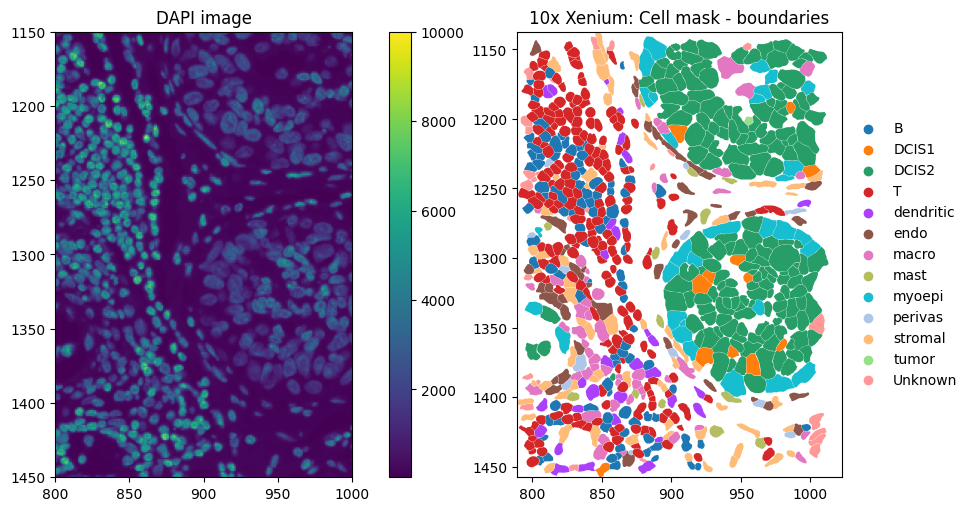

In [6]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata.pl.render_images("image").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot - Cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

labels = sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    # palette=cols,
    groups=labels,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

Before we continue, we extract the `anndata` object from our `spatialdata` object, and perform both normalization and a log-transform on the expression matrix.

In [7]:
adata = sdata.tables["table"]
# Store raw counts
adata.layers["raw"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [8]:
adata

AnnData object with n_obs × n_vars = 743 × 5101
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'label_id', 'region', 'transcript_count', 'gene_count', 'transferred_cell_type', 'pearson_score', 'transferred_cell_type_plot'
    uns: 'spatialdata_attrs', 'log1p'
    layers: 'raw'

#### Compute positive and negative markers (per cell type)

Some genes are only expressed by certain cell types. This means that we can compute which genes we do or do not see in specific cell types. We call these positive or negative markers.

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [9]:
# subsetting our spatial proteomics dataset to only contain genes that also appear in the scRNA-seq data
common_genes = adata.var_names[adata.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [10]:
# computing the positive and negative markers for each cell type
# the result is a dict with your cell type as keys (B, T, etc.) and another dict as values,
# which tell you the positive or negative markers for each cell type
markers = segtraq.get_ref_markers(adata_ref, 
                                  ref_cell_type="celltype_major", 
                                  method = "t-test",
                                  pval_adj_thresh= 0.05, 
                                  logfc_pos_thresh = 1.0, 
                                  logfc_neg_thresh = -1.0, 
                                  # max_fpr = 0.4,
                                  # auc_pos_thresh = 0.75,
                                  # auc_neg_thresh = 0.75,
                                  # vote_fraction_neg=0.0,
                                  # vote_fraction_pos=0.0,
                                  n_jobs = 16)

t-test

In [11]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]
    
    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: MS4A1, BANK1, SP140, CD79A, PARP15, BLK, TNFRSF13B, TNFRSF13C, POU2AF1, AIM2, PAX5, FCRL1, TLR10, CD79B, FCRL2, PLCG2, ST6GAL1, PTPN6, P2RX5, POU2F2, CD19, FCRL5, SCIMP, FCRLA, CNR2, COL4A3, FCRL3, ANKRD13A, COCH, CXCR5, PDK1, DPF3, ANGPTL6, FCER2, TNR, NCR3, GDF7, CR2, DNAH8, FCRL4, CD22, ADAM28, PTK2B, TBC1D10C, CD52, FCMR, CR1, SP110, CDK14, ZC3H12D, TLR6, KCNN4, ITGB7, CD27, SMCHD1, ZBP1, COL4A4, STAP1, NCOA3, CCR6, TNFRSF17, APOBEC3C, SLAMF6, ICAM3, ADGRG5, PNOC, ORAI2, SH2B2, TFEB, ABCB4, KLHL14, KCNIP2, ANK1, CD70, TSHR, NETO1, SGCA, HTR3A, FXYD7, GLRA3, SYVN1, WDFY4, SELL, NCF1, CYSLTR1, ACP5, LPAR5, APOBEC3D, CD72, IFT57, LPIN1, BTLA, IL7, IRF5, NUAK2, LTA, STK33, IGHE, ANKK1, IGF2BP3, BCL2, FAM117B, NCF4, CASP10, MCM5, APOBEC3F, C2orf88, TOX, TRAF5, BTN3A1, CTRL, PKIA, AGMAT, HTR4, BFSP2, GLCCI1, RLN2, PRKCG, CD47, SYNRG, NFKB2, PSIP1, CSK, SLC12A6, TESK2, DMXL1, CHD7, FANCD2
B  |  negative: GNAQ, ATF3, CD109, GNS, ACVR2A, PON2, MAOA, IGF2BP2, CTTNBP2NL, TPPP3

AUC based

In [36]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]
    
    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: BANK1, MS4A1, SP140, CD79A
B  |  negative: 

DCIS1  |  positive: SLC12A2, IKZF3, ITGB6, MZB1, AGR2, CEACAM5, ERBB2, NQO1, PHB, PRKAR1A, ANKRD30A, DDR1, GATA3, IGFBP2, SLC30A8, TFAP2A, XBP1, ITGA3, MLPH, SLC16A1, BCAM, G6PD, GIPC1, PTPRF, LASP1, CD151, FASN, FOXA1, MAL2, MYO6, ST14, MCM3AP, CFB, DHCR24, EPCAM, GRHL2, MIEN1, PLXNB1, PROM2, SDC4, ALCAM, AMH, BAIAP2, CDH1, CLDN7, CTNNA1, CTTN, EHF, EPHB4, EPHX1, ERBB3, FZD6, GNA11, IL13RA1, ITGB4, JUP, KIAA1324, MAP7, NECTIN1, NECTIN2, PAK4, PIK3R2, PITX1, SCAMP4, TRPM4, TSPAN13, SOD1, TRPS1, BCAR1, BCL2L2, CORO1B, CTNND1, DST, FAAH, FADS2, HK2, ICA1, IFNGR2, PLAT, PPP1R37, SREBF1, VEGFA, ABHD11, APMAP, BCL6, CCND1, CDK4, DMPK, ECE1, FOXP4, HNRNPF, HSPA8, HSPB1, INPP4B, ITPR3, KPNA2, LDLR, LMX1B, LRATD2, MACC1, METTL2A, MRFAP1L1, NDUFAB1, NINJ1, P4HB, PAWR, PDCD6, PKM, PPM1D, PPP1R7, RAC1, RGL3, SBNO2, SH3GLB2, SLC2A1, SRA1, STAU1, TC2N, TCEA3, TLK2, TNFRSF1A, TOP1, TRIM47, TUBB, TUBD1, UFC1, UGDH, YWHAQ, LAMP1, PPP1R9B
DCI

Let's check our positive markers for all cell types.

In [11]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]
    
    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: MS4A1, BANK1, SP140, CD79A, PARP15, TNFRSF13B, BLK, TNFRSF13C, POU2AF1, AIM2, PAX5, FCRL1, CD79B, TLR10, FCRL2, PLCG2, ST6GAL1, P2RX5, POU2F2, PTPN6, CD19, FCRL5, SCIMP, CD22, ADAM28, PTK2B, TBC1D10C, CD52, FCMR, CR1, ZC3H12D, SP110, CDK14, TLR6, ITGB7, KCNN4, CD27, SMCHD1, STAP1, FCRLA, NCOA3, COL4A3, FCRL3, ANKRD13A, WDFY4, SELL, CCDC141, ZBP1, PIM2, COL4A4, TNFRSF17, CNR2, ADGRG5, SYVN1, NCF4, CD38, CCR6, SLAMF6, CYSLTR1, COCH, CXCR5, PNOC, ANGPTL6, BCL2, PDK1, TRAF5, CASP10, BTN3A1, CLNK, FCER2, CD72, CNR1, CD47, SYNRG, APOBEC3C, NFKB2, DPF3, ICAM3, LPAR5, DMXL1, ORAI2
B  |  negative: PON2, GNAQ, GNS, ZYX, TSPAN14, ARRB1, SPECC1, BACE1, EGLN3, RBMS2, CD109, NREP, FZD4, ATL3, RTL8C, AGAP3, NACC2, SLC3A2, MICAL2, CAMK1, GPRC5B, OLFM1, PLD1, CDKN2B, LGALSL, MAFF, SPATA7, GRAMD2B, CTTNBP2NL, GAS2L1, PODXL, VAMP5, ALDH7A1, FZD1, PTPDC1, NRSN2, CLCN5, TIAM1, PTGFRN, PLA2R1, DUSP23, SNX30, HNRNPLL, NFE2L2, ACVR2A, PCDHB14, ACVR1B, ZMIZ1, FMN1, CYP27A1, DAPK1, TSPO, NECTIN1

The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

#### Find mutually exclusive marker pairs

Our next goal is to find pairs of markers that never occur together (they are "mutually exclusive", i.e. if one marker is seen in a cell, we expect the second marker not to be expressed in the same cell). We identify those pairs of genes on the scRNA-seq dataset.

Mutually exclusive gene pairs are identified by scanning each cell type’s positive markers, keeping genes expressed in >20% of that type but <5% of all other cells and retaining only genes that satisfy this criterion for a single type. It then returns all cross-type combinations of these type-unique genes as (gene1, gene2) pairs.

In [16]:
# computing pairs of mutually exclusive genes
mut_excl_marker_pairs = segtraq.get_mut_excl_markers(
    markers=markers
)

In [17]:
mut_excl_marker_pairs

{('B', 'DCIS1'): [('APOBEC3C', 'AAR2'),
  ('APOBEC3C', 'BCL3'),
  ('APOBEC3C', 'BLVRA'),
  ('APOBEC3C', 'MPP7'),
  ('APOBEC3C', 'OSGIN1'),
  ('APOBEC3C', 'PER3'),
  ('APOBEC3C', 'SSX2IP'),
  ('CBLN3', 'AAR2'),
  ('CBLN3', 'BCL3'),
  ('CBLN3', 'BLVRA'),
  ('CBLN3', 'MPP7'),
  ('CBLN3', 'OSGIN1'),
  ('CBLN3', 'PER3'),
  ('CBLN3', 'SSX2IP'),
  ('PRKD3', 'AAR2'),
  ('PRKD3', 'BCL3'),
  ('PRKD3', 'BLVRA'),
  ('PRKD3', 'MPP7'),
  ('PRKD3', 'OSGIN1'),
  ('PRKD3', 'PER3'),
  ('PRKD3', 'SSX2IP'),
  ('TRAF5', 'AAR2'),
  ('TRAF5', 'BCL3'),
  ('TRAF5', 'BLVRA'),
  ('TRAF5', 'MPP7'),
  ('TRAF5', 'OSGIN1'),
  ('TRAF5', 'PER3'),
  ('TRAF5', 'SSX2IP')],
 ('B', 'DCIS2'): [('ATP2B1', 'CTBP2'),
  ('ATP2B1', 'NRIP1'),
  ('ATP2B1', 'OLFM1'),
  ('ATP2B1', 'OSGIN1'),
  ('TFEB', 'CTBP2'),
  ('TFEB', 'NRIP1'),
  ('TFEB', 'OLFM1'),
  ('TFEB', 'OSGIN1')],
 ('B', 'T'): [],
 ('B', 'dendritic'): [],
 ('B', 'endo'): [('LPAR5', 'ALPK3'),
  ('LPAR5', 'CTTNBP2NL'),
  ('LPAR5', 'GAS2L1'),
  ('LPAR5', 'GPRC5B'),
  ('LPAR

#### Compute mutually exclusive co-expression rate (MECR) per gene pair

Now that we know which markers should never occur together, we can compute the mutually exclusive co-expression rate (MECR) on our spatial transcriptomics data.

The MECR per gene pair in the spatial transcriptomics dataset can be calculated using the `sp.compute_MECR()` method. The MECR measures how often two genes are co-detected relative to how often either is detected, i.e. `MECR = P(both>0) / P(g1>0 ∪ g2>0)`. An MECR of 0 means that the gene pair never co-occurred, which we would expect for our mutually exclusive markers. Non-zero values indicate that there might be some contamination going on.

In [18]:
st.sp.compute_MECR(gene_pairs=mut_excl_marker_pairs)

({('MS4A1', 'SHD'): np.float64(1.857434245840043),
  ('MS4A1', 'TCL1A'): np.float64(3.3205946152864616),
  ('MS4A1', 'TLR9'): np.float64(3.469198239899423),
  ('BANK1', 'SHD'): np.float64(1.0559981255857545),
  ('BANK1', 'TCL1A'): np.float64(0.0),
  ('BANK1', 'TLR9'): np.float64(9.232537351551526),
  ('CD79A', 'SHD'): np.float64(0.9864007755158565),
  ('CD79A', 'TCL1A'): np.float64(1.1005300788954635),
  ('CD79A', 'TLR9'): np.float64(3.080055210489993),
  ('TNFRSF13B', 'SHD'): np.float64(3.0337566844919786),
  ('TNFRSF13B', 'TCL1A'): np.float64(0.0),
  ('TNFRSF13B', 'TLR9'): np.float64(6.082219251336898),
  ('CD22', 'SHD'): np.float64(0.0),
  ('CD22', 'TCL1A'): np.float64(1.9764409379793995),
  ('CD22', 'TLR9'): np.float64(1.7513597513597514),
  ('TNFRSF13C', 'SHD'): np.float64(1.8252247623940405),
  ('TNFRSF13C', 'TCL1A'): np.float64(2.037871853546911),
  ('TNFRSF13C', 'TLR9'): np.float64(0.877785446657464),
  ('POU2AF1', 'SHD'): np.float64(1.700865616574429),
  ('POU2AF1', 'TCL1A'): 

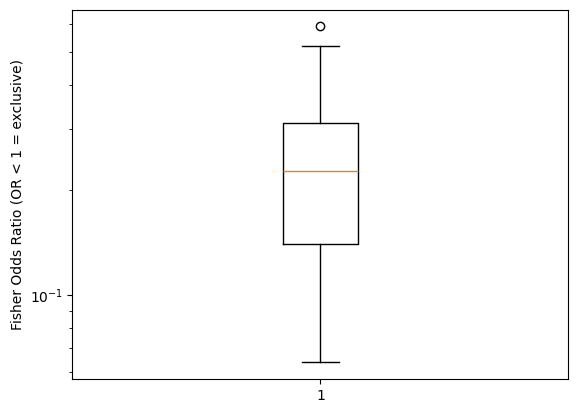

In [21]:
or_dict = sdata["table"].uns["Fisher_OR"]
pval_dict = sdata["table"].uns["Fisher_pval"]
signif_pairs = [
    (g1, g2) for (g1, g2), p in pval_dict.items()
    if p is not None and p < 0.01 and or_dict[(g1, g2)] < 1 and or_dict[(g1, g2)] > 0
]

data = [ [or_dict[pair] for pair in signif_pairs]]
plt.boxplot(data)
plt.ylabel("Fisher Odds Ratio (OR < 1 = exclusive)")
plt.yscale("log")  # optional, odds ratios vary strongly
plt.show()

In [13]:
# computing the MECR
mecr = st.sp.compute_MECR(gene_pairs=mut_excl_marker_pairs)

# mecr is a dictionary
# let's look at the first 5 entries
for i, (k, v) in enumerate(mecr.items()):
    print(k, v)
    if i == 4:
        break

NameError: name 'mut_excl_marker_pairs' is not defined

For each gene pair, we now have an MECR value. Let's investigate the distribution of those values

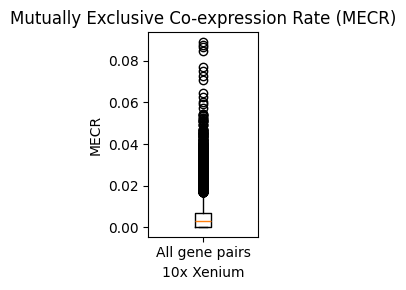

In [15]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(2, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["All gene pairs"])
plt.tight_layout()
plt.show()

In [16]:
vals_nz = [x for x in vals if x > 0]  # non zero
print(f"{100 * (len(vals_nz) / len(vals)):.2f}% of gene pairs that should be mutually exclusive have a non-zero MECR.")
print(f"Median MECR = {np.median(vals_nz)}, variance = {np.var(vals_nz)}")

58.63% of gene pairs that should be mutually exclusive have a non-zero MECR.
Median MECR = 0.006060606060606061, variance = 3.913937618643064e-05


Over all gene pairs, 53% of the gene pairs found to be mutually exclusive in the reference scRNA-seq dataset have non-zero MECR with a median of 0.005.
To get a better picture of this effect, we can check the MECR per cell type. This will tell us if there are any cell type specific biases.

#### Computing the MECR for pairs of cell types

We can also compute the mutually exclusive genes for pairs of cell types. To do this, we once again use the function `sp.get_mut_excl_markers()`, but now we specify the `cell_types` parameter (which is a tuple of cell types).

In [17]:
# computing pairs of mutually exclusive genes
mut_excl_markers_b_t = segtraq.get_mut_excl_markers(
    adata_ref,
    ref_cell_type="celltype_major",
    markers=markers,
    pos_threshold=0.2,
    neg_threshold=0.05,
    max_codetect=0.01,
    cell_types=("B", "T"),
)
mut_excl_markers_b_t[::10]

[('MS4A1', 'LCK'),
 ('MS4A1', 'CD40LG'),
 ('BANK1', 'CD8A'),
 ('CD79A', 'SLAMF1'),
 ('TNFRSF13B', 'CD247'),
 ('BLK', 'IL2RB'),
 ('CD22', 'GZMA'),
 ('TNFRSF13C', 'CD5'),
 ('POU2AF1', 'BCL11B'),
 ('PAX5', 'CD3G'),
 ('AIM2', 'ITK'),
 ('FCRL1', 'LCK'),
 ('FCRL1', 'CD40LG'),
 ('CD79B', 'CD8A'),
 ('FCRL2', 'SLAMF1'),
 ('P2RX5', 'CD247'),
 ('NIBAN3', 'IL2RB'),
 ('CD19', 'GZMA'),
 ('FCRL5', 'CD5'),
 ('SCIMP', 'BCL11B'),
 ('DERL3', 'CD3G')]

In [28]:
new_set_canon

{('ACAP1', 'MS4A1'),
 ('ACAP1', 'PARP15'),
 ('ACAP1', 'PTK2B'),
 ('ACAP1', 'SP140'),
 ('BANK1', 'THEMIS'),
 ('BANK1', 'TRAF3IP3'),
 ('CD2', 'PARP15'),
 ('CD2', 'PTK2B'),
 ('CD2', 'SP140'),
 ('CD3D', 'MS4A1'),
 ('CD3D', 'PARP15'),
 ('CD3D', 'PTK2B'),
 ('CD3D', 'SP140'),
 ('CD3E', 'MS4A1'),
 ('CD3E', 'PARP15'),
 ('CD3E', 'PTK2B'),
 ('CD3E', 'SP140'),
 ('CD52', 'MS4A1'),
 ('CD52', 'PARP15'),
 ('CD52', 'PTK2B'),
 ('CD52', 'SP140'),
 ('CD6', 'MS4A1'),
 ('CD6', 'PARP15'),
 ('CD6', 'PTK2B'),
 ('CD6', 'SP140'),
 ('CD96', 'PARP15'),
 ('CD96', 'PTK2B'),
 ('CD96', 'SP140'),
 ('ETS1', 'MS4A1'),
 ('ETS1', 'PARP15'),
 ('ETS1', 'PTK2B'),
 ('ETS1', 'SP140'),
 ('ITGAL', 'MS4A1'),
 ('ITGAL', 'PARP15'),
 ('ITGAL', 'PTK2B'),
 ('ITGAL', 'SP140'),
 ('KLRK1', 'MS4A1'),
 ('KLRK1', 'PARP15'),
 ('KLRK1', 'PTK2B'),
 ('KLRK1', 'SP140'),
 ('MS4A1', 'NLRC5'),
 ('MS4A1', 'OGT'),
 ('MS4A1', 'SLFN5'),
 ('MS4A1', 'TBC1D10C'),
 ('MS4A1', 'THEMIS'),
 ('MS4A1', 'TRAF3IP3'),
 ('MS4A1', 'TRBC1'),
 ('MS4A1', 'ZAP70'),
 ('NLR

Now that we have mutually exclusive marker pairs for our B and T cells, we can once again compute the MECR, but now specific to B and T cells.

In [18]:
# computing the MECR
mecr = st.sp.compute_MECR(gene_pairs=mut_excl_markers_b_t)

# mecr is a dictionary
# let's look at the first 5 entries
for i, (k, v) in enumerate(mecr.items()):
    print(k, v)
    if i == 4:
        break

('AIM2', 'BCL11B') 0.0
('AIM2', 'CD247') 0.007374631268436577
('AIM2', 'CD3G') 0.0035971223021582736
('AIM2', 'CD40LG') 0.0
('AIM2', 'CD5') 0.005758157389635316


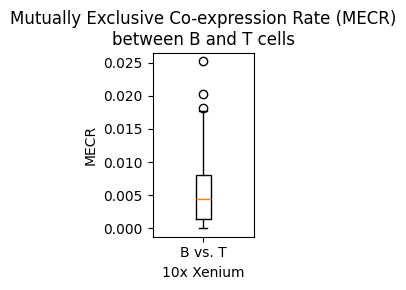

In [19]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(2, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)\nbetween B and T cells")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["B vs. T"])
plt.tight_layout()
plt.show()

In [20]:
# TODO: need some better validation that this works here!

#### Evaluate positive and negative marker purity

From our MECR calculations, we know that there are some genes which co-occur when they shouldn't, hinting at some form of contamination. A next logical step would be to identify the cells where this is the case. To do this, we can calculate the marker purity for each cell.

Positive and negative marker purity in the spatial transcriptomics datasets can be computed via `sp.calculate_marker_purity()`. It evaluates, for each cell, how well its expected positive markers are among the cell’s top-expressed genes and how well the negative markers are not among those top genes, using a quantile/rank threshold based on the size of each marker list. From this it computes precision, recall, and F1 for both marker sets and combines them into a single “purity” score that rewards strong positive signal and penalizes negative signal. The output is a per-cell table of these metrics alongside the annotated cell type.

In [12]:
purity_df = st.sp.calculate_marker_purity(cell_type_key="transferred_cell_type", markers=markers)
purity_df.head()

,positive_precision,positive_recall,positive_F1,negative_precision,negative_recall,negative_F1,F1_purity
cell_id,,,,,,,
aphcnklp-1,0.470588,0.062992,0.111111,0.529412,0.009698,0.019048,0.199612
aphdnoam-1,1.000000,0.043860,0.084034,0.000000,0.000000,0.000000,0.155039
aphdpfhl-1,1.000000,0.081871,0.151351,0.000000,0.000000,0.000000,0.262911
aphebebn-1,1.000000,0.096491,0.176000,0.000000,0.000000,0.000000,0.299320
aphejokb-1,1.000000,0.070175,0.131148,0.000000,0.000000,0.000000,0.231884


/tmp/ipykernel_3590580/3300367728.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby("transferred_cell_type_plot")["F1_purity"].median().sort_values(ascending=False).index


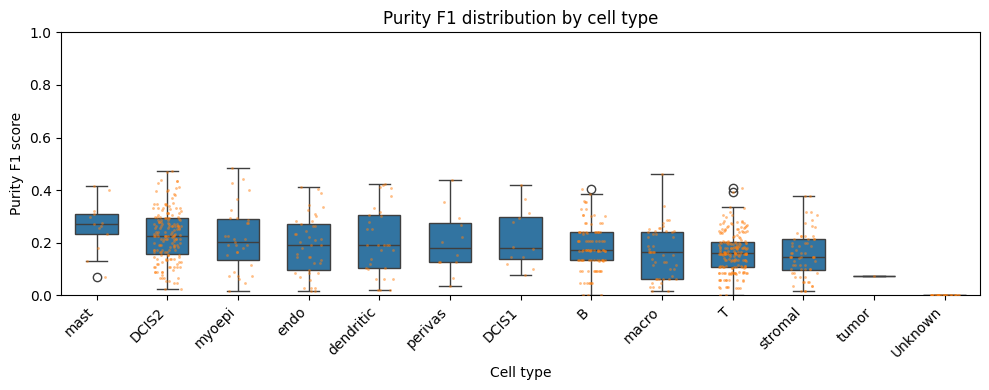

In [13]:
# plotting the distribution of the purity F1 score per cell type
df = adata.obs[["transferred_cell_type_plot", "F1_purity"]].dropna()

order = df.groupby("transferred_cell_type_plot")["F1_purity"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="transferred_cell_type_plot", y="F1_purity", order=order, width=0.6)
sns.stripplot(data=df, x="transferred_cell_type_plot", y="F1_purity", order=order, alpha=0.5, size=2, jitter=0.2)

plt.ylim(0, 1)
plt.xlabel("Cell type")
plt.ylabel("Purity F1 score")
plt.title("Purity F1 distribution by cell type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
# getting the median F1 purity score per cell type
df.groupby("transferred_cell_type_plot")["F1_purity"].median()

/tmp/ipykernel_29284/882471183.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("transferred_cell_type_plot")["F1_purity"].median()


transferred_cell_type_plot
B            0.100711
DCIS1        0.077397
DCIS2        0.098566
T            0.105161
dendritic    0.084074
endo         0.141208
macro        0.109622
mast         0.110316
myoepi       0.082622
perivas      0.090626
stromal      0.122186
tumor        0.039590
Unknown      0.000000
Name: F1_purity, dtype: float64

From the plot and the median values, we can see that the cell type "tumor" yields the lowest purity F1 score, while DCIS2 has the highest one. 

#### Neigbhorhood contamination

Let's check which cell types are responsible for this contamination. Use the `sp.calculate_contamination()` function to quantify directional “leakage” between cell types in spatial data: for each `ct` cell, it uses a spatial neighbors graph (computed with `squidpy`) to measure what share of ct-specific positive-marker signal appears inside neighboring `ct2` cells, then averages these fractions into a ct→ct2 matrix. 

Higher entries suggest spillover rather than true biology.

In [24]:
k_df, cont_df_diag, cont_df = st.sp.calculate_contamination(
    markers=markers,
    cell_type_key="transferred_cell_type",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

We can visualize the pairwise contamination between cell types in the form of a heatmap.

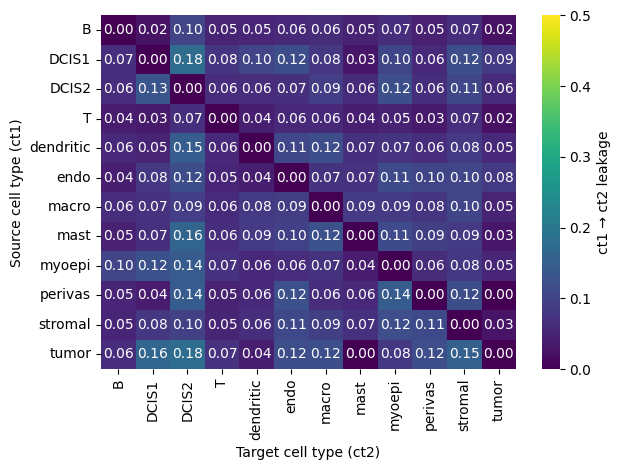

In [25]:
ax = sns.heatmap(
    cont_df_diag, vmin=0, vmax=0.5, cmap="viridis", annot=True, fmt=".2f", cbar_kws={"label": "ct1 → ct2 leakage"}
)
ax.set_xlabel("Target cell type (ct2)")
ax.set_ylabel("Source cell type (ct1)")
plt.tight_layout()

#### Differential expression between adjacent and non-adjacent cell types

To assess the effect of spillover, we can do a differential expression test between cells one cell type bordering another cell type vs. those not bordering that cell type. For example, consider all B cells. We now want to know if B cells that are close to T cells have a different expression profile to B cells which are not next to any T cells.

The algorithm works as follows:
- Construct a neighborhood graph (Delaunay)
- for every marker, ct1 and ct2:
    - get all cells of ct1
    - subset them into those that are next to cells of ct2 (group1) and those that are not next to cells of ct2 (group2)
    - Only continue if there are at least 20 cells in each group
    - do a differential expression test between the groups (Wilcoxon rank-sum on normalized and log-transformed counts)
    - Remove genes which have less than 20 transcripts in both groups combined
    - Only keep genes that are supposed to be negative in ct1 and positive in ct2
- result: for each (gene, ct1, ct2), we get a log fold change and a p-value

A couple of important things to note here:
- we only look at genes that are negative in the "receiver" cell type, and positive in the "sender" cell type (from which the spillover originates). We use the definition of "negative" and "positive" markers from earlier
- since we specifically want to look at spillover events, we only look at genes with a high log fold change (LFC), and ignore the ones with a low LFC

In [26]:
sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/xenium.zarr
├── Images
│     └── 'image': DataArray[cyx] (1, 1795, 1519)
├── Labels
│     ├── 'cell_labels': DataArray[yx] (1795, 1519)
│     └── 'nucleus_labels': DataArray[yx] (1795, 1519)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (18311, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (18608, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (18311, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [ ]:
de_results, de_summary = st.sp.calculate_diff_abundance(
    markers=markers,
    pval_thresh=0.05,
    lfc_thresh=10,
    cell_type_key="transferred_cell_type",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
de_results.head()

We can start interpreting the results by looking at a volcano plot of the results. We will show all events in this plot, and color them by the receiving cell (indicated as `ct1`).

In [ ]:
# creating a volcano plot
plt.figure(figsize=(6, 5))
for ct, color in col_celltype.items():
    sub = de_results[de_results["ct1"] == ct]
    plt.scatter(sub["log2FC"], -np.log10(sub["pval"]), c=color, label=ct, alpha=0.6, s=10)
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("log2FC")
plt.ylabel("-log10(p-value)")
plt.legend(markerscale=2)
plt.title("Volcano plot of spatial DE")
plt.show()

We can also check the number of events we found with our thresholds for each sender(`ct2`)/receiver(`ct1`) pair.

In [ ]:
# sns.heatmap(de_summary)

It looks like all of our spillover is caused by DCIS2 cells spilling over into cells of another cell type. Let's visualize some of our supposed spillover events spatially.

In [ ]:
de_results.sort_values(by="log2FC", ascending=False).head()

In [ ]:
axes = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)[1]

# Plot - Cell boundaries
sdata.pl.render_shapes(
    "cell_boundaries", color="transferred_cell_type_plot", palette=["deepskyblue", "gold"], groups=["DCIS1", "DCIS2"]
).pl.render_points("transcripts", color="feature_name", groups="CLTC", palette="black").pl.show(
    ax=axes, title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)